# Lab 2: Classification Using KNN and RNN Algorithms

Name: Bishnu Sharma  
Course: MSCS 634 – Advanced Data Mining  
Date: March 20, 2026

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score

## Dataset Description
The dataset used in this lab is the Wine dataset from scikit-learn, originally sourced from the UCI Machine Learning Repository. It contains 178 samples with 13 numerical features representing chemical properties of wine. The dataset is divided into three classes.

In [2]:
wine = load_wine()

X = wine.data
y = wine.target

df = pd.DataFrame(X, columns=wine.feature_names)
df['target'] = y

df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Dataset Exploration

In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (178, 14)


In [4]:
df['target'].value_counts()

target
1    71
0    59
2    48
Name: count, dtype: int64

## Train-Test Split
The dataset is split into 80% training data and 20% testing data to evaluate model performance on unseen data.

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (142, 13)
Testing size: (36, 13)


## K-Nearest Neighbors (KNN) Classification

In [6]:
k_values = [1, 5, 11, 15, 21]
knn_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    knn_accuracies.append(acc)
    print(f"k={k}, Accuracy={acc}")

k=1, Accuracy=0.9444444444444444
k=5, Accuracy=0.9444444444444444
k=11, Accuracy=0.9444444444444444
k=15, Accuracy=0.9722222222222222
k=21, Accuracy=0.9444444444444444


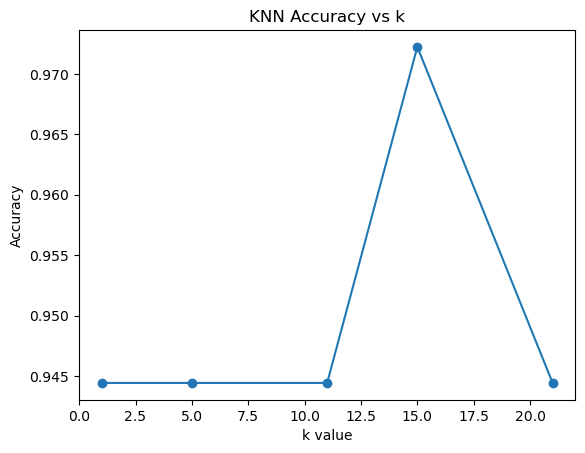

In [7]:
plt.plot(k_values, knn_accuracies, marker='o')
plt.xlabel("k value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs k")
plt.show()

## KNN Observations

The KNN classifier shows that accuracy depends on the value of k. Smaller values of k (such as k=1) may lead to overfitting, as the model becomes sensitive to noise in the data.

As the value of k increases, the model becomes more generalized and stable. However, very large values of k may reduce accuracy due to oversmoothing.

Overall, moderate values of k provide the best balance between bias and variance.

## Radius Neighbors (RNN) Classification

In [8]:
radius_values = [350, 400, 450, 500, 550, 600]
rnn_accuracies = []

for r in radius_values:
    rnn = RadiusNeighborsClassifier(radius=r, outlier_label=0)
    rnn.fit(X_train, y_train)

    y_pred = rnn.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    rnn_accuracies.append(acc)
    print(f"radius={r}, Accuracy={acc}")

radius=350, Accuracy=0.3888888888888889
radius=400, Accuracy=0.3888888888888889
radius=450, Accuracy=0.3888888888888889
radius=500, Accuracy=0.3888888888888889
radius=550, Accuracy=0.3888888888888889
radius=600, Accuracy=0.3888888888888889


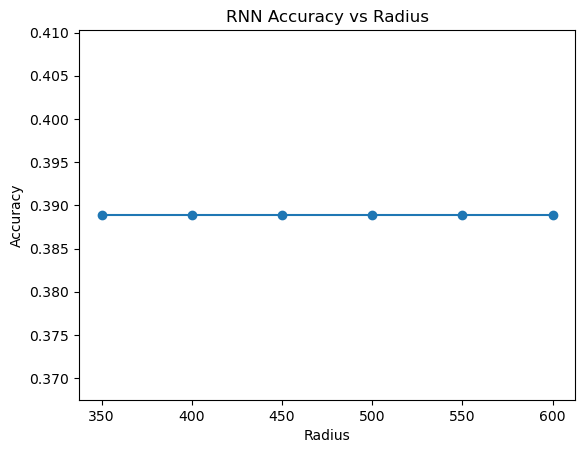

In [9]:
plt.plot(radius_values, rnn_accuracies, marker='o')
plt.xlabel("Radius")
plt.ylabel("Accuracy")
plt.title("RNN Accuracy vs Radius")
plt.show()

## RNN Observations

The Radius Neighbors classifier is highly sensitive to the chosen radius value. Smaller radius values may not include enough neighbors, leading to lower accuracy.

Larger radius values include more neighbors but may introduce noise and reduce model performance.

Compared to KNN, RNN performance varies more due to its dependence on data distribution and scaling.

## Model Comparison and Insights

The KNN classifier provides more stable and consistent accuracy across different parameter values because it always considers a fixed number of neighbors.

In contrast, the RNN classifier depends on a distance threshold, making it more sensitive to the dataset's distribution and feature scaling.

Overall, KNN performs better on this dataset due to its stability and reliability, while RNN may be useful in cases where data density varies significantly.

## When to Use KNN vs RNN

KNN is preferable when the dataset has uniform density and when a fixed number of neighbors is desired.

RNN is more suitable for datasets with varying densities, where grouping based on distance is more meaningful.